# 06 Model Evaluation

This notebook evaluates the trained PM2.5 regression models using:
- R2 score
- MAE
- RMSE
- actual vs predicted plot
- residual distribution

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path.cwd()
AQI_DIR = BASE_DIR / "data" / "AQI"
HTML_DIR = BASE_DIR / "data" / "html_data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
X_test_processed = joblib.load(ARTIFACTS_DIR / "pm25_X_test_processed.joblib")
y_test = joblib.load(ARTIFACTS_DIR / "pm25_y_test.joblib")
model_names = joblib.load(ARTIFACTS_DIR / "pm25_trained_model_names.joblib")

evaluation_rows = []
predictions_map = {}

for name in model_names:
    safe_name = name.lower().replace(" ", "_")
    model = joblib.load(ARTIFACTS_DIR / f"{safe_name}_model.joblib")
    predictions = model.predict(X_test_processed)
    predictions_map[name] = predictions
    evaluation_rows.append({
        "model": name,
        "r2_score": r2_score(y_test, predictions),
        "mae": mean_absolute_error(y_test, predictions),
        "rmse": np.sqrt(mean_squared_error(y_test, predictions))
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("r2_score", ascending=False).reset_index(drop=True)
evaluation_df

,model,r2_score,mae,rmse
0,Gradient Boosting,0.872432,17.625271,23.949747
1,XGBoost,0.860860,17.787336,25.012398
2,Random Forest,0.826107,21.552097,27.962182
3,AdaBoost,0.825043,22.789601,28.047571
4,Extra Trees,0.798482,22.666251,30.101414
5,SVR,0.570403,29.131151,43.950171
6,KNN,0.512606,30.625501,46.813358


In [3]:
best_model_name = evaluation_df.iloc[0]["model"]
best_predictions = predictions_map[best_model_name]

print("Best model:", best_model_name)
print("Best R2 score:", evaluation_df.iloc[0]["r2_score"])
print("Best MAE:", evaluation_df.iloc[0]["mae"])
print("Best RMSE:", evaluation_df.iloc[0]["rmse"])

Best model: Gradient Boosting
Best R2 score: 0.8724319149496274
Best MAE: 17.625271256450414
Best RMSE: 23.949746518074615


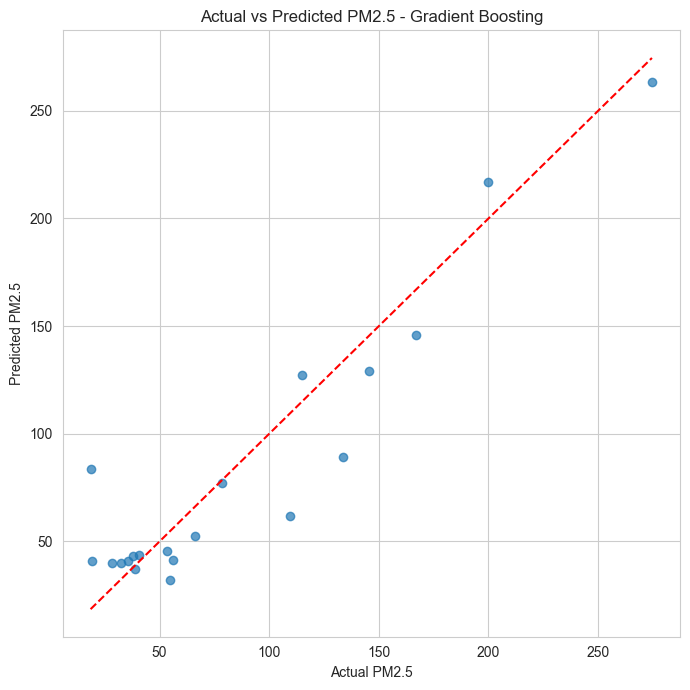

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.7)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title(f"Actual vs Predicted PM2.5 - {best_model_name}")
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.tight_layout()
plt.show()

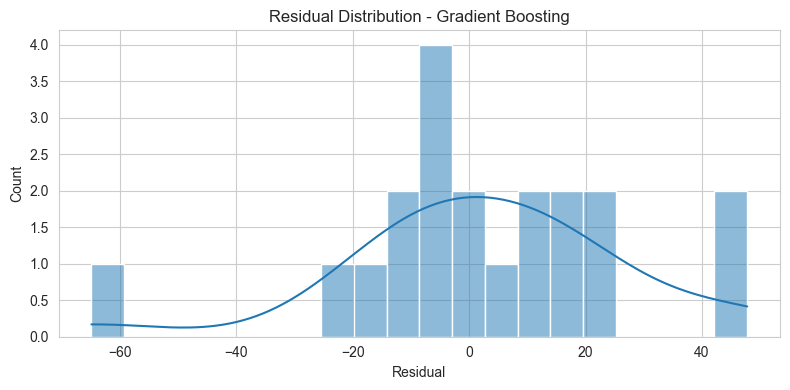

In [5]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=20, kde=True)
plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

In [6]:
evaluation_df.to_csv(ARTIFACTS_DIR / "pm25_model_evaluation_results.csv", index=False)
print("Saved PM2.5 evaluation summary.")

Saved PM2.5 evaluation summary.
